In [9]:
print ("hello this ready")

hello this ready


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("✓ All libraries loaded!")

✓ All libraries loaded!


In [11]:
!pip install plotly

In [12]:
df = pd.read_csv('../data/raw/winemag-data-130k-v2.csv')
df

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129966,129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.0,Mosel,NaN,NaN,Anna Lee C. Iijima,NaN,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,129967,US,Citation is given as much as a decade of bottl...,NaN,90,75.0,Oregon,Oregon,Oregon Other,Paul Gregutt,@paulgwine,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
129968,129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss


In [13]:
df.sample(10)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
123117,123117,US,"Dark and spicy blackcurrant fruit, black-cherr...",NaN,88,28.0,California,Santa Clara Valley,Central Coast,Matt Kettmann,@mattkettmann,Jason-Stephens 2013 Cabernet Sauvignon (Santa ...,Cabernet Sauvignon,Jason-Stephens
7909,7909,US,"Not much going on beyond simple jam, currant a...",NaN,84,45.0,California,Napa Valley,Napa,NaN,NaN,The Full 2011 Cabernet Sauvignon (Napa Valley),Cabernet Sauvignon,The Full
46932,46932,Italy,This shows more oak-driven sensations than you...,Balsina,88,47.0,Piedmont,Ghemme,NaN,Kerin O’Keefe,@kerinokeefe,Ioppa 2011 Balsina (Ghemme),Red Blend,Ioppa
106622,106622,Chile,Edgy plum and berry aromas come with an herb a...,Edición Limitada,87,23.0,Loncomilla Valley,NaN,NaN,Michael Schachner,@wineschach,Morandé 2008 Edición Limitada Carignan (Loncom...,Carignan,Morandé
28773,28773,US,"Melon, sea salt and white peach aromatics lean...",Camp 4 Vineyard,91,24.0,California,Santa Ynez Valley,Central Coast,Matt Kettmann,@mattkettmann,Shane Wines 2014 Camp 4 Vineyard Grenache Blan...,Grenache Blanc,Shane Wines
48626,48626,Argentina,Tropical aromas revolve around lemon-lime. Thi...,Ampakama,84,11.0,Other,San Juan,NaN,Michael Schachner,@wineschach,Casa Montes 2014 Ampakama Chardonnay (San Juan),Chardonnay,Casa Montes
122476,122476,Italy,"Aromas of menthol, ripe berry, dark spice and ...",NaN,88,46.0,Piedmont,Barolo,NaN,Kerin O’Keefe,@kerinokeefe,Brezza 2012 Barolo,Nebbiolo,Brezza
63365,63365,Argentina,Raisiny black-fruit aromas are jammy and a cla...,Reserva,88,19.0,Mendoza Province,Mendoza,NaN,Michael Schachner,@wineschach,Bodega Norton 2011 Reserva Malbec (Mendoza),Malbec,Bodega Norton
18944,18944,Italy,"Soft and plush, this blend of Montepulciano (8...",Ramitello,91,18.0,Southern Italy,Biferno Rosso,NaN,NaN,NaN,Di Majo Norante 2010 Ramitello (Biferno Rosso),Red Blend,Di Majo Norante
21278,21278,US,Intriguing notes of sandalwood and cedar meet ...,La Gioja,87,29.0,California,Santa Ynez Valley,Central Coast,Matt Kettmann,@mattkettmann,Martellotto 2014 La Gioja Merlot (Santa Ynez V...,Merlot,Martellotto


Observations: 
1. Remove unnamed columns, taster name, taste twitter handle, region2
2. Province are there for most of them, but region information is missing for some
3. Need to clean title, description
4. Potentially remove designation since we already have winery given
5. Clean title, description, country, province, region1, and veriety

In [14]:
# Drop some columns
# inplace = True means the dataFrame is modified in place
df.drop(["Unnamed: 0", "taster_name", "taster_twitter_handle"], axis=1, inplace=True)
df

,country,description,designation,points,price,province,region_1,region_2,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks
...,...,...,...,...,...,...,...,...,...,...,...
129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.0,Mosel,NaN,NaN,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,US,Citation is given as much as a decade of bottl...,NaN,90,75.0,Oregon,Oregon,Oregon Other,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   country      129908 non-null  object 
 1   description  129971 non-null  object 
 2   designation  92506 non-null   object 
 3   points       129971 non-null  int64  
 4   price        120975 non-null  float64
 5   province     129908 non-null  object 
 6   region_1     108724 non-null  object 
 7   region_2     50511 non-null   object 
 8   title        129971 non-null  object 
 9   variety      129970 non-null  object 
 10  winery       129971 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 10.9+ MB


Observation
1. The types of all the features is correct. So, price is float64 and points is int64.

In [19]:
df.isnull().sum().sort_values(ascending=True)

description        0
points             0
title              0
winery             0
variety            1
country           63
province          63
price           8996
region_1       21247
designation    37465
region_2       79460
dtype: int64

Observation: 
1. Both country and province are missing the same number of missing values. It could be country and province has same missing rows. 

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
points,129971.0,88.447138,3.039730,80.0,86.0,88.0,91.0,100.0
price,120975.0,35.363389,41.022218,4.0,17.0,25.0,42.0,3300.0


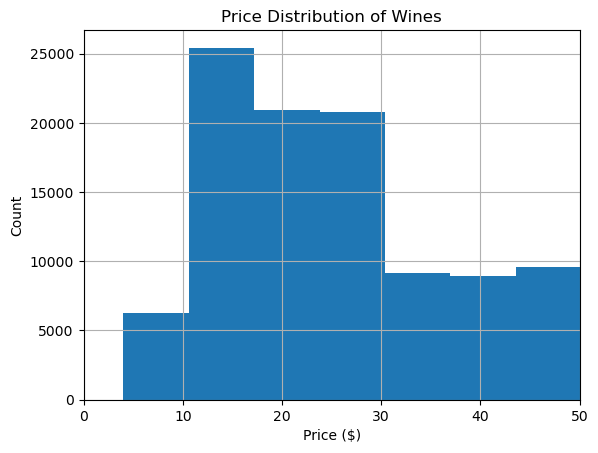

In [75]:
# Price distribution
df['price'].hist(bins=500)
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.title('Price Distribution of Wines')
# Update the scale of the graph
plt.xlim(0,50)
plt.show()

Observation
1. Data is left-skewed, so we can apply a log transform to it.
2. More than 25000 wines are priced between $10 and $20
3. We had to change the range of the x-axis from 0 - 50 to properly visualize the data

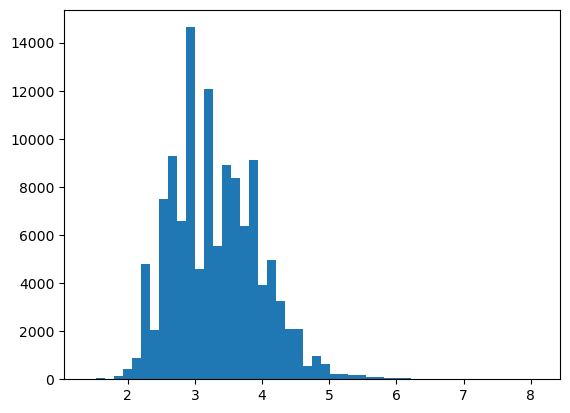

In [66]:
# Logarithmic plot to convert the left skewed data into a vieqw
plt.hist(np.log(df['price']), bins=50)
plt.show()

Observation
1. This has removed skewness
2. We will add this logarithmic values into our dataframe

In [94]:
# We will 
(df['price']>100).sum()

np.int64(3366)